# Wishart H / A / Alpha classification

This notebook shows how to apply the Wishart unsupervised classification to a PolSARpro NetCDF dataset.

## Import packages and set directories

In [1]:
import os 
from pathlib import Path
import xarray as xr
from polsarpro.io import open_netcdf_beam
from polsarpro.classification import wishart_h_a_alpha

# optional import for progress bar
from dask.diagnostics import ProgressBar

# change to your data paths
# original dataset
input_alos_data = Path("/data/psp/test_files/SAN_FRANCISCO_ALOS1_slc.nc")
output_dir = Path("/data/psp/res")


## Load data

We load the SNAP NetCDF-BEAM dataset using the `open_netcdf_beam` function. 
To obtain such a dataset, please refer to the "Getting Started" tutorial or the `quickstart-tutorial.ipynb` notebook.

In [2]:
# uncomment to test on S matrix made with SNAP
S = open_netcdf_beam(input_alos_data)

## Apply the classification

Let's apply the algorithm and write the result to a NetCDF file.
Optionally we can use a progress bar to monitor the progress of the computation.

**Note:** Unlike the C implementation, this version does not require precomputed H/A/Alpha parameters. However, for backward compatibility, you may provide existing parameters via the h_a_alpha_result argument. In that case, the H/A/Alpha parameters may have been computed using a different boxcar window size than the one used in this function.

In [3]:
# change to the name of your liking
file_out = output_dir / "psp_wishart_haa.nc"

# netcdf writer cannot overwrite
if os.path.isfile(file_out):
    os.remove(file_out)

with ProgressBar():
    wishart_h_a_alpha(S, boxcar_size=[7, 7]).to_netcdf(file_out)

[########################################] | 100% Completed | 264.04 s


## Display outputs

We open the previously saved dataset:

In [4]:
res = xr.open_dataset(file_out)

Then we may plot the individual outputs:

### 8 Classes based on H/Alpha

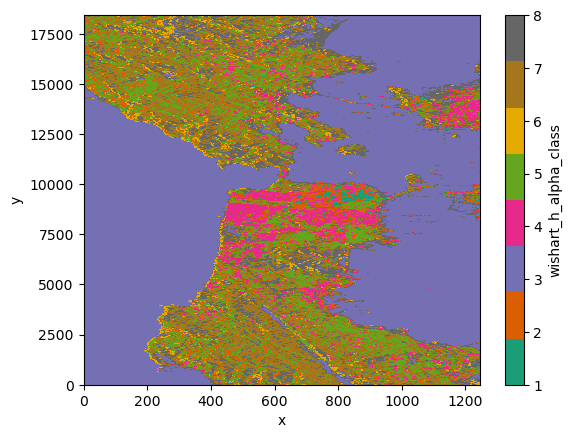

In [8]:
res.wishart_h_alpha_class.plot.imshow(cmap="Dark2")

### 16 Classes based on H/A/Alpha

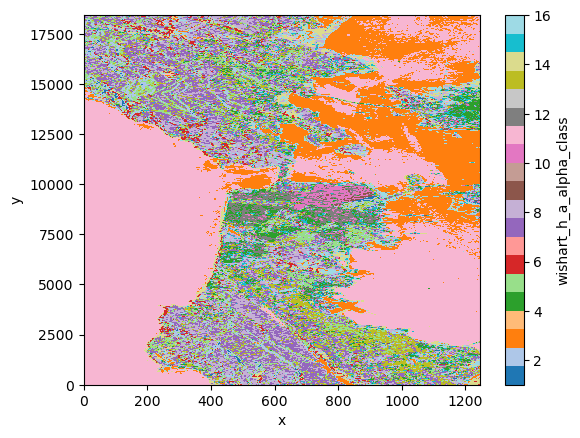

In [ ]:
res.wishart_h_a_alpha_class.plot.imshow(cmap="tab20")